## Mercedes Global Car Sales 2020-2025 

### Mercedes Global Car Sales 2020-2025
 Name : Saikumar Lakkaram
 
 
Student Id : GH1047507

Subject: M504A Ai & Applications

#### Dataset link: https://www.kaggle.com/datasets/dhrubangtalukdar/mercedes-global-car-sales-2020-2025/data

#### Git Hub link:

## What is the Problem?

Understanding Mercedes sales across the global from year 2020 - 2025

 BUSSINESS QUESTIONS

 1.How much total revenue was generated by Mercedes?

 2.What are the sales trends for Mercedes between 2020-2025, and which year is highest record?
 
3.Which Mercedes models recorded the highest sales volume between 2020 and 2025, and which model is the market leader?

4.What is the price distribution of Mercedes vehicles, and which price range has highest frequency?

5.Which fuel type is the most popular among Mercedes constumers,and how does it compare to other categories?

6.How does the Horsepower change for different Mercedes models?

7.Which colors are most popular among Mercedes buyers?

8.How are the differnt features like Price and Horsepower related to each other?

## Bussiness Problem:

Mercedes Benz has many different car models with various prices, engines, and power levels. Even though they sell a lot of cars, the company wants to know exactly what makes a car successful. They are not sure which models make the most money or what kind of fuel (like Petrol or Electric) customers actually prefer. They also want to understand if things like price and engine power really affect how many cars are sold. By looking at the sales data, Mercedes-Benz wants to find out which cars they should focus on more and how to set the right prices. This analysis will help the company make better decisions about which cars to produce and how to attract more customers in the future?

# Importing Python libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

# Data Collection

In [2]:
df=pd.read_csv(r"C:\Users\saiku\Downloads\mercedes_benz_sales_2020_2025.csv")

In [3]:
df

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo
0,A-Class,2020,Global,Yellow,Diesel,41265,252,1,Yes
1,A-Class,2020,Global,Black,Petrol,51023,249,1,No
2,A-Class,2020,Global,Grey,Petrol,72819,341,1,Yes
3,A-Class,2020,Global,Black,Petrol,62480,385,1,Yes
4,A-Class,2020,Global,White,Petrol,35189,337,1,Yes
...,...,...,...,...,...,...,...,...,...
12132661,AMG S 63,2025,Global,Silver,Electric,219647,811,1,Yes
12132662,AMG S 63,2025,Global,Grey,Electric,251632,799,1,Yes
12132663,AMG S 63,2025,Global,Grey,Hybrid,260947,803,1,Yes
12132664,AMG S 63,2025,Global,Grey,Electric,311030,792,1,Yes


In [4]:
df.head() 

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo
0,A-Class,2020,Global,Yellow,Diesel,41265,252,1,Yes
1,A-Class,2020,Global,Black,Petrol,51023,249,1,No
2,A-Class,2020,Global,Grey,Petrol,72819,341,1,Yes
3,A-Class,2020,Global,Black,Petrol,62480,385,1,Yes
4,A-Class,2020,Global,White,Petrol,35189,337,1,Yes


# Data Exploration

In [5]:
df.dtypes

Model               object
Year                 int64
Region              object
Color               object
Fuel Type           object
Base Price (USD)     int64
Horsepower           int64
Sales Volume         int64
Turbo               object
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12132666 entries, 0 to 12132665
Data columns (total 9 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   Model             object
 1   Year              int64 
 2   Region            object
 3   Color             object
 4   Fuel Type         object
 5   Base Price (USD)  int64 
 6   Horsepower        int64 
 7   Sales Volume      int64 
 8   Turbo             object
dtypes: int64(4), object(5)
memory usage: 833.1+ MB


In [7]:
df.shape

(12132666, 9)

# Checking Duplictaes

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.shape

(12129513, 9)

In [10]:
df.isnull().sum()   

Model               0
Year                0
Region              0
Color               0
Fuel Type           0
Base Price (USD)    0
Horsepower          0
Sales Volume        0
Turbo               0
dtype: int64

In [11]:
import missingno 

<Axes: >

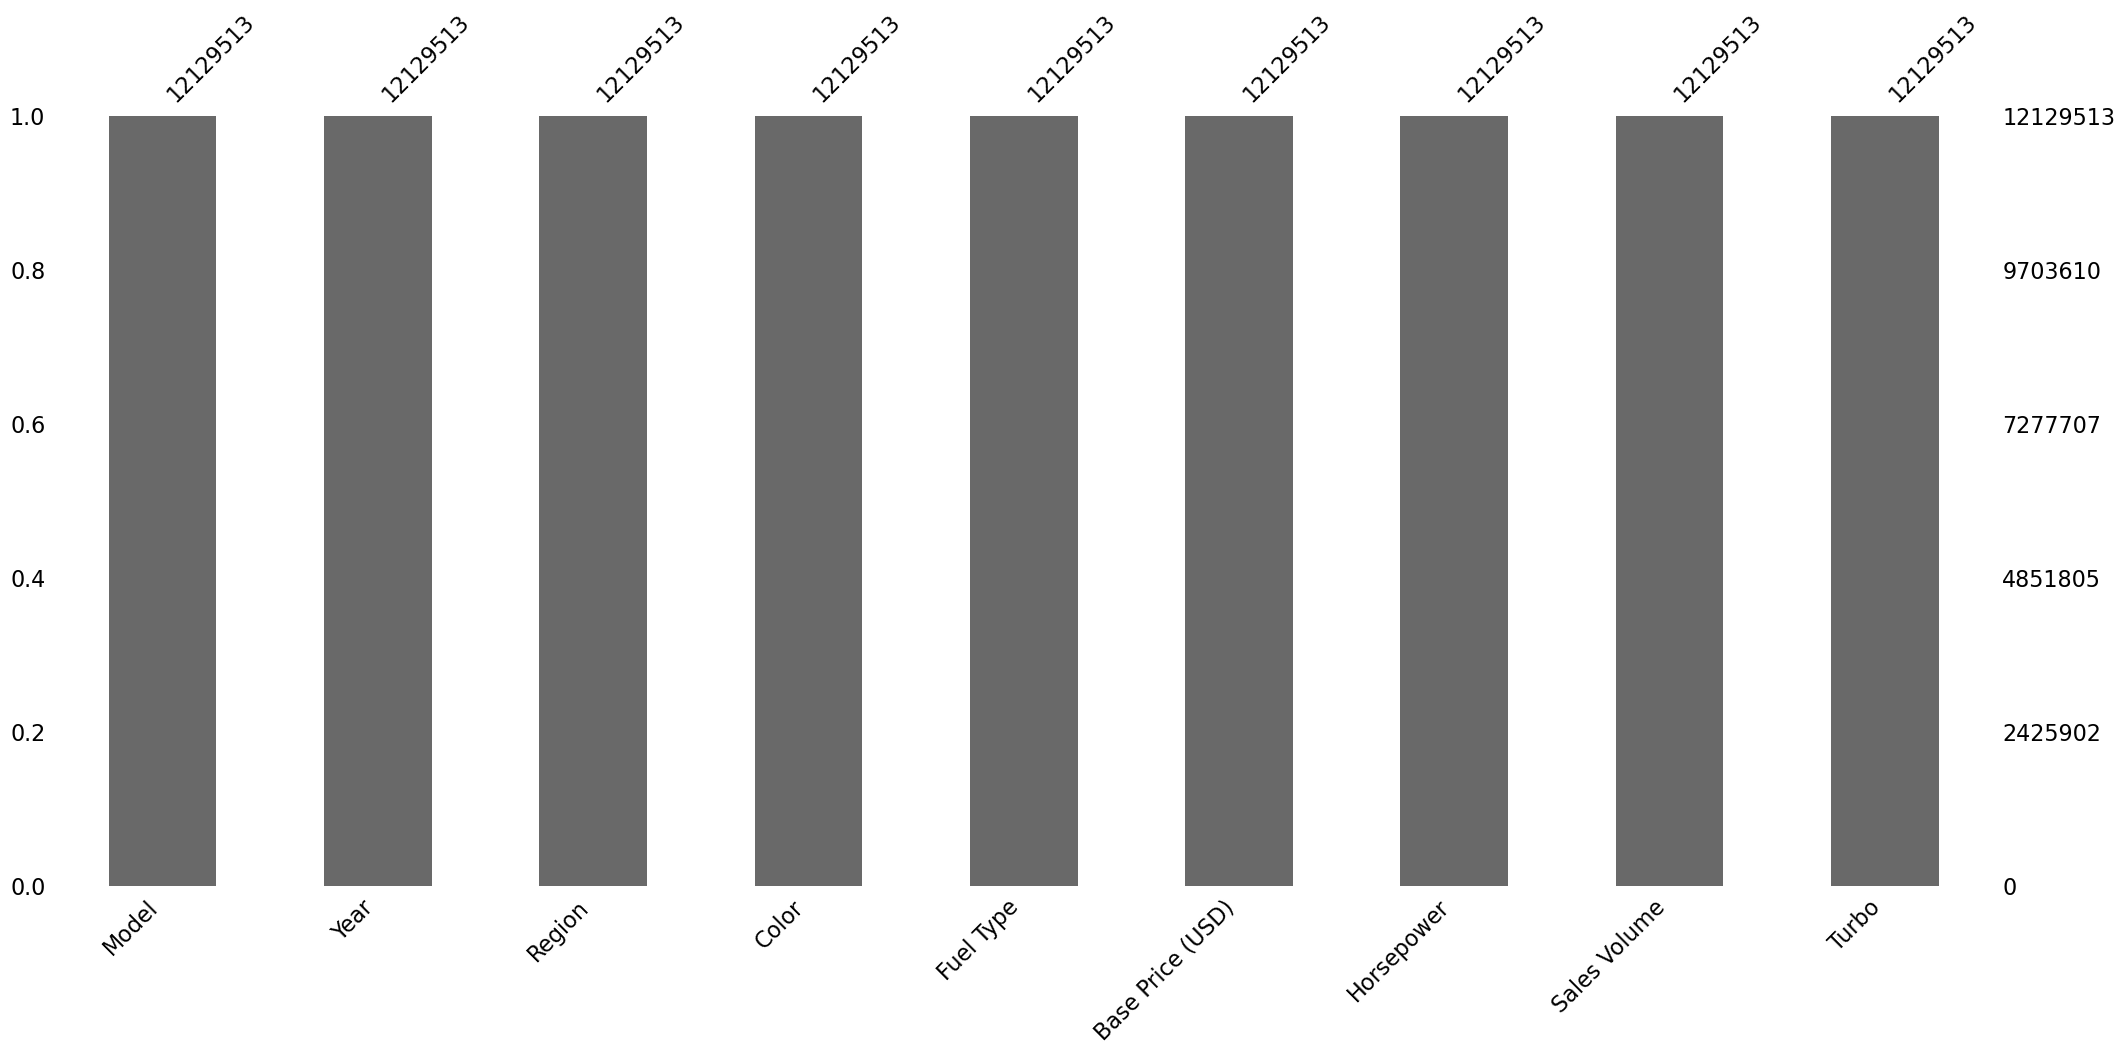

In [12]:
missingno.bar(df)  

In [25]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:")
print(categorical_cols)            

Categorical columns:
Index(['Model', 'Region', 'Color', 'Fuel Type', 'Turbo'], dtype='object')


In [26]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:")
print(numerical_cols)

Numerical columns:
Index(['Year', 'Base Price (USD)', 'Horsepower', 'Sales Volume'], dtype='object')


In [15]:
df.describe()

,Year,Base Price (USD),Horsepower,Sales Volume
count,1.212951e+07,1.212951e+07,1.212951e+07,12129513.0
mean,2.022548e+03,1.042226e+05,3.674664e+02,1.0
std,1.658897e+00,6.783929e+04,1.195476e+02,0.0
min,2.020000e+03,3.500000e+04,1.500000e+02,1.0
25%,2.021000e+03,6.346400e+04,2.750000e+02,1.0
50%,2.023000e+03,8.357400e+04,3.580000e+02,1.0
75%,2.024000e+03,1.199280e+05,4.440000e+02,1.0
max,2.025000e+03,4.112460e+05,8.310000e+02,1.0


In [16]:
df

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo
0,A-Class,2020,Global,Yellow,Diesel,41265,252,1,Yes
1,A-Class,2020,Global,Black,Petrol,51023,249,1,No
2,A-Class,2020,Global,Grey,Petrol,72819,341,1,Yes
3,A-Class,2020,Global,Black,Petrol,62480,385,1,Yes
4,A-Class,2020,Global,White,Petrol,35189,337,1,Yes
...,...,...,...,...,...,...,...,...,...
12132661,AMG S 63,2025,Global,Silver,Electric,219647,811,1,Yes
12132662,AMG S 63,2025,Global,Grey,Electric,251632,799,1,Yes
12132663,AMG S 63,2025,Global,Grey,Hybrid,260947,803,1,Yes
12132664,AMG S 63,2025,Global,Grey,Electric,311030,792,1,Yes


## How much total revenue was generated by Mercedes from year 2020-2025?

Total Revenue: 1264168945179


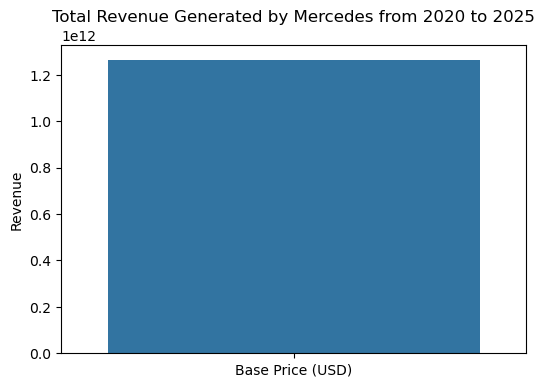

In [27]:
total_revenue = df['Base Price (USD)'].sum()       
print("Total Revenue:", total_revenue)
plt.figure(figsize=(6,4))
sns.barplot(x=['Base Price (USD)'], y=[total_revenue])  
plt.title('Total Revenue Generated by Mercedes from 2020 to 2025')
plt.ylabel('Revenue')
plt.show()   

The bar chart shows the total Revenue by Mercedes from all their cars. In total, they earned over 1.26 Trillion dollar, which is a big amount.

This high number proves that Mercedes is a leader in the luxury car market. It gives us a clear idea of how big the business is before we look into more details like specific car models or engine types.

## What are the sales trends for Mercedes between 2020-2025, and which year is highest record?

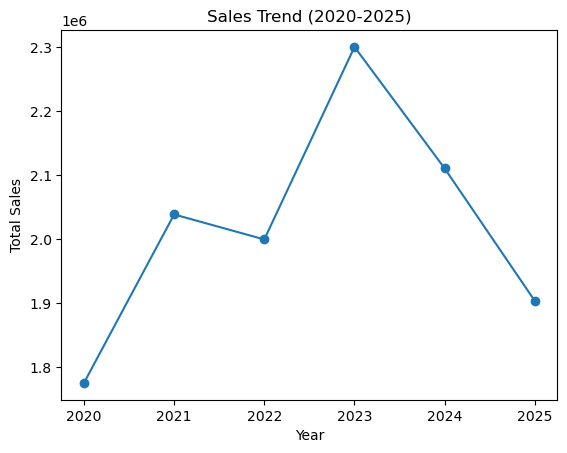

In [18]:
yearly_sales = df.groupby('Year')['Sales Volume'].sum()
yearly_sales.plot(marker='o')
plt.title('Sales Trend (2020-2025)')
plt.ylabel('Total Sales')
plt.show()

This line chart shows how the sales changed year after year. We can see that more people started buying cars from 2020, and the sales reached a peak in 2023 with about 2.3 million cars sold.

After 2023, the sales slowly started to go down in 2024 and 2025. This helps the company understand which years were the best for their business and when they need to improve their sales strategy again.

## Which Mercedes models recorded the highest sales volume between 2020 and 2025, and which model is the market leader?

C:\Users\saiku\AppData\Local\Temp\ipykernel_18032\2940797470.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_models.values, y=top_models.index, palette='viridis')


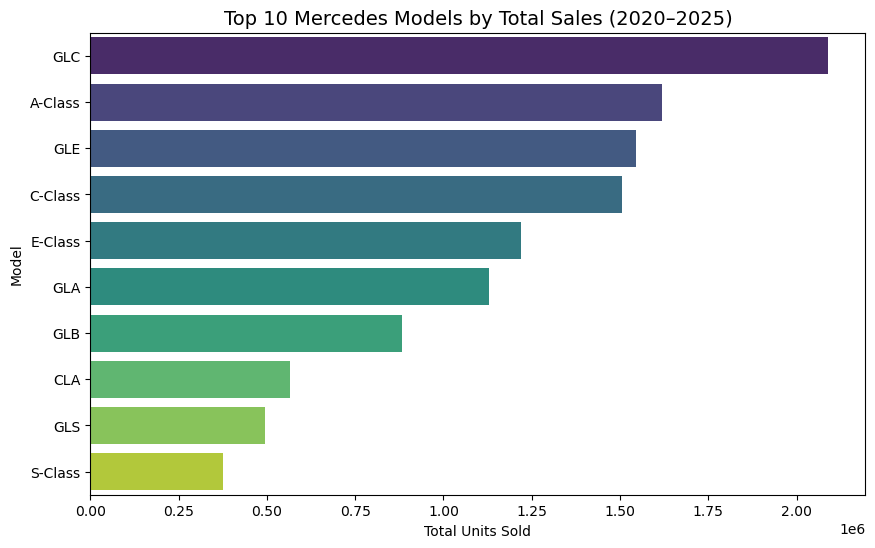

In [19]:
top_models = df.groupby('Model')['Sales Volume'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_models.values, y=top_models.index, palette='viridis')
plt.title('Top 10 Mercedes Models by Total Sales (2020–2025)', fontsize=14)
plt.xlabel('Total Units Sold')
plt.ylabel('Model')
plt.show()


This bar chart shows which Mercedes cars people are buying the most. The GLC is the most popular model, with the A Class and GLE following closely behind.

It is clear that bigger family style cars and smaller luxury models are the main reason for the company's high sales. This information helps Mercedes decide which types of cars they should keep making to stay successful.

## What is the price distribution of Mercedes vehicles, and which price range has highest frequency?

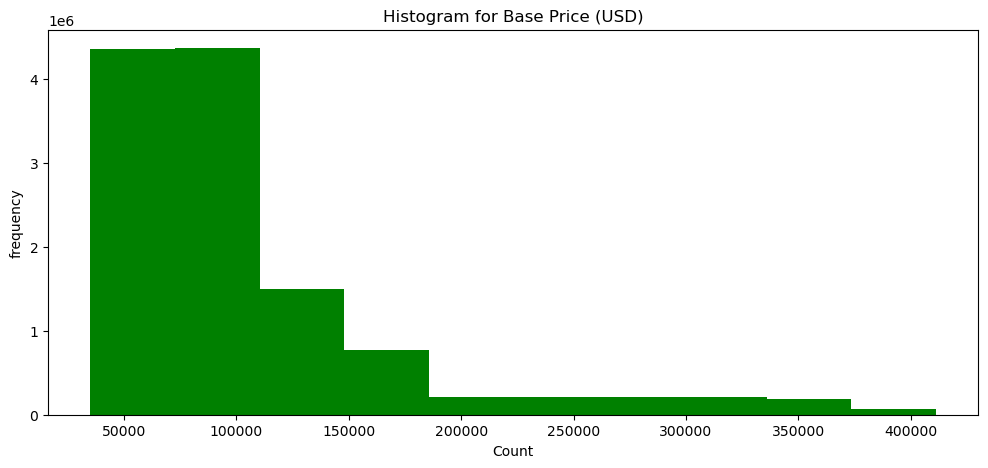

In [20]:
plt.figure(figsize=(12,5))
plt.hist(df['Base Price (USD)'],bins =10,color = 'green')
plt.xlabel('Count')
plt.ylabel('frequency')
plt.title('Histogram for Base Price (USD)' )
plt.show()

This Histogram chart shows the distribution of prices of these cars are spread out. We can see that most Mercedes cars are priced between 50,000 dollars & 100,000 dollars.

As the prices get higher, the number of cars sold becomes much smaller. This tells us that even though it is a luxury brand, most of their business comes from the more affordable price ranges rather than the very expensive models.

 ## Which fuel type is the most popular among Mercedes constumers, and how does it compare to other categories?

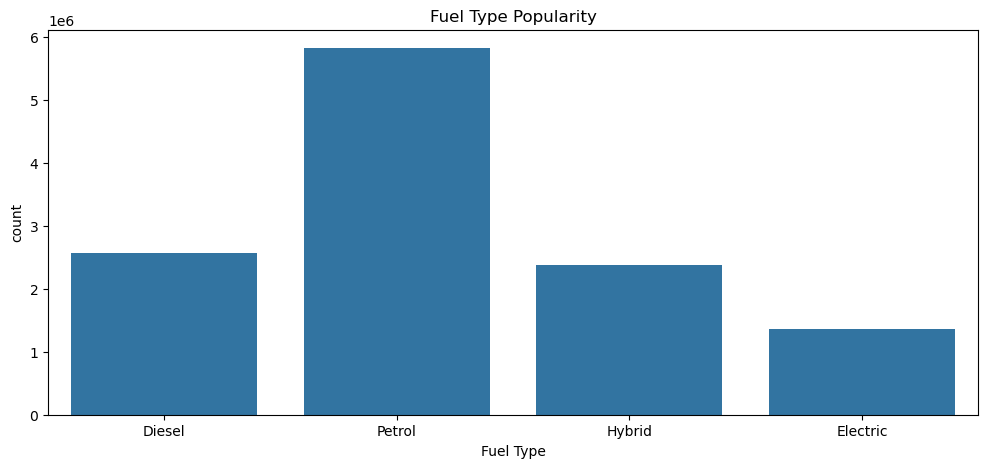

In [21]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='Fuel Type')
plt.title('Fuel Type Popularity')
plt.show()

This chart compares the different types of fuel people choose. Petrol is the most popular choice by far, as most customers still prefer it over anything else.

Diesel and Hybrid cars have almost the same level of popularity. Even though Electric cars have the lowest sales right now, they still show that some people are starting to move toward cleaner energy. This helps the company understand what kind of engines they should focus on for the future.

## How does the Horsepower change for different Mercedes models?

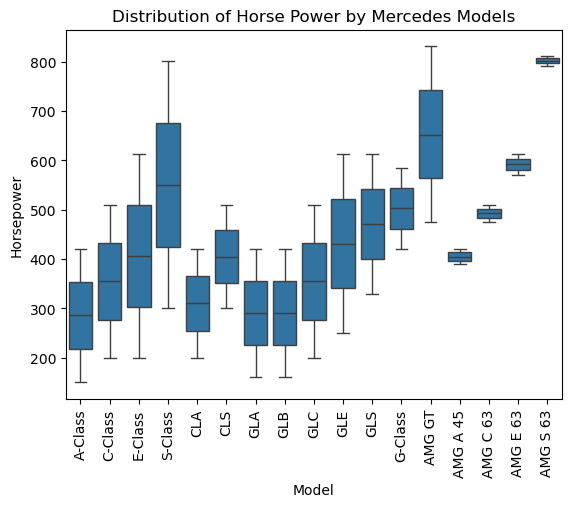

In [22]:
sns.boxplot(data=df,y='Horsepower',x='Model')
plt.title("Distribution of Horse Power by Mercedes Models")
plt.xticks(rotation=90) 
plt.show()

This chart shows how much Horsepower each car model has. We can see that sports models like the AMG GT and AMG S 63 have the most power, going up to 800 HP.

Regular cars like the A Class have much lower power, which stays around the same level for all its versions. This clearly shows that Mercedes has two main groups of cars, one for normal luxury driving and another for high speed performance.

## Which colors are most popular among Mercedes buyers?

C:\Users\saiku\AppData\Local\Temp\ipykernel_18032\3077629496.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=color_counts.values, y=color_counts.index, palette='muted')


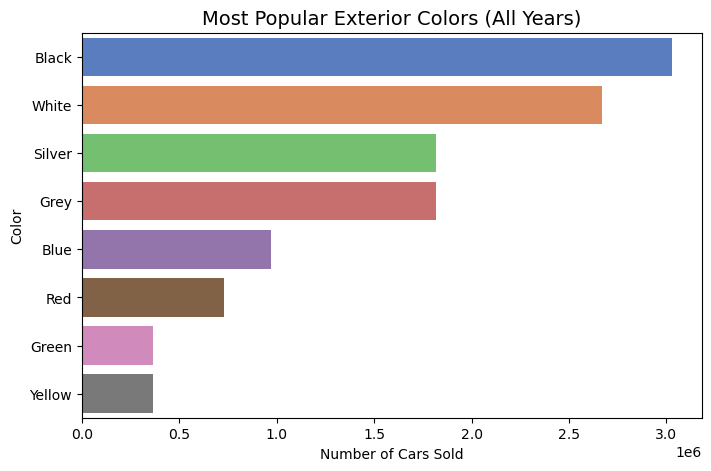

In [23]:
color_counts = df['Color'].value_counts().head(8)

plt.figure(figsize=(8, 5))
sns.barplot(x=color_counts.values, y=color_counts.index, palette='muted')
plt.title('Most Popular Exterior Colors (All Years)', fontsize=14)
plt.xlabel('Number of Cars Sold')
plt.ylabel('Color')
plt.show()


This chart shows which colors people like the most when buying a Mercedes. It’s no surprise that Black is the number one choice, with White coming in a close second.

Classic colors like Silver and Grey are also very popular. On the other hand, very few people choose bright colors like Yellow or Green. This tells the company that most of their customers prefer a more professional and classic look for their luxury cars.

## How are the different features like Price and Horsepower related to each other?

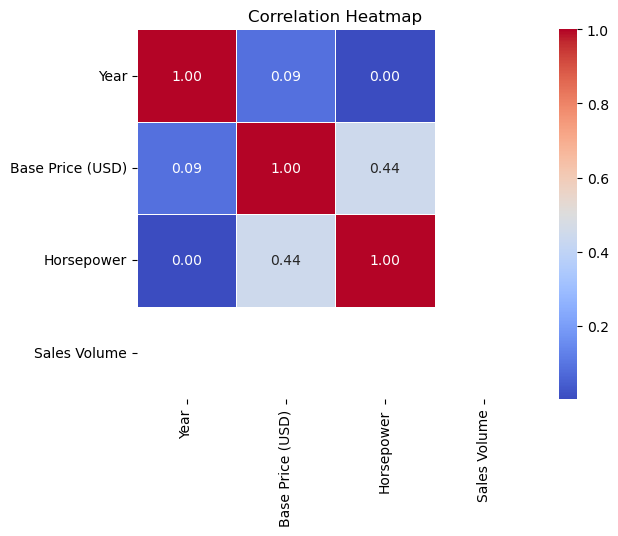

In [24]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

This heatmap shows how different things in our data are linked together. The most important link we found is between Price and Horsepower, which has a score of 0.44. This basically tells us that as the engine power goes up, the price of the car usually goes up too.

Other things, like the year the car was made, don't really change the price that much. This chart helps the company understand that engine performance is the biggest factor that decides how much they can charge for a car.

## Data-Driven Recommendations

Mercedes should focus more on their topperforming models like the GLC and A Class, as these cars are the main reason for the high sales volume. Since most customers choose cars priced between 50,000 and 100,000, the company can improve its revenue by offering more customized options or better financing plans in this specific price range to attract more buyers.

Regarding fuel types, it is clear that Petrol remains the most popular choice for customers, while Electric and Hybrid models are still growing slowly. Instead of stopping Petrol production, the company should continue to support it while gradually increasing their marketing for Electric cars. This will help them keep their current profits while slowly preparing for the future shift toward cleaner energy.

The data also shows that engine performance is a huge factor in car pricing, with a clear link of 0.44 between horsepower and price. Mercedes should use this in their marketing by highlighting the high power of their AMG models to justify the premium cost. Additionally, sticking to classic colors like Black and White for the majority of their stock will help reduce the risk of having unsold cars in less popular colors like Yellow or Green.

## Conclusion

To conclude, this project gives us a clear picture of how Mercedes has performed over the last few years. By looking at the data, we can see that the company is in a very strong position, making over 1.2 Trillion in revenue. Even though sales reached their highest point in 2023 and then slowed down slightly, the brand remains highly successful because it offers a wide range of models that fit different customer needs.

The analysis shows that customers have very specific preferences when it comes to their luxury cars. Most buyers still trust Petrol engines the most and prefer classic colors like Black and White. We also found that people are willing to pay more for cars with higher engine power, which is why the AMG models are so valuable to the brand. While the company is starting to see some interest in Electric and Hybrid cars, these are still growing and haven't overtaken traditional engines yet.

Overall, the most important takeaway is that Mercedes success comes from balancing high performance sports cars with more affordable luxury models like the GLC. By focusing on these popular models and keeping an eye on the growing demand for new fuel types, Mercedes can continue to lead the market and stay ahead of its competitors in the coming years.